<a href="https://colab.research.google.com/github/ob3x/Learn-Ds/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

np.set_printoptions(precision=8, suppress=True, edgeitems=5, linewidth=200)

In [ ]:
from sklearn.datasets import load_iris

raw_data = load_iris()
data = raw_data["data"]
target = raw_data["target"]
feature_names = list(raw_data["feature_names"])
target_names = [name.replace(' ', '_')[:-5] for name in feature_names]
df = pd.DataFrame(data=np.c_[data, target], columns=feature_names + ["class"])
df["class"] = df["class"].map(dict(zip(range(3), target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,sepal_length
1,4.9,3.0,1.4,0.2,sepal_length
2,4.7,3.2,1.3,0.2,sepal_length
3,4.6,3.1,1.5,0.2,sepal_length
4,5.0,3.6,1.4,0.2,sepal_length


In [ ]:
px.scatter_3d(df, x="sepal length (cm)", y="petal length (cm)", z="petal width (cm)", template="plotly_dark", color="class", title="Iris data - wizualizacja 3D", opacity=0.5, width=950, height=500)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, [0,2,3]]
y = df.iloc[:, -1]

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std[:5]

array([[-0.90068117, -1.34022653, -1.3154443 ],
       [-1.14301691, -1.34022653, -1.3154443 ],
       [-1.38535265, -1.39706395, -1.3154443 ],
       [-1.50652052, -1.2833891 , -1.3154443 ],
       [-1.02184904, -1.34022653, -1.3154443 ]])

In [ ]:
cov_mat = np.cov(X_std, rowvar=False)
cov_mat

array([[1.00671141, 0.87760447, 0.82343066],
       [0.87760447, 1.00671141, 0.96932762],
       [0.82343066, 0.96932762, 1.00671141]])

In [ ]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print(f"Wartości własne:\n{eig_vals}\n")
print(f"Wektory własne:\n{eig_vecs}")

Wartości własne:
[2.78833033 0.20075012 0.03105378]

Wektory własne:
[[ 0.55964149  0.81270446  0.16221241]
 [ 0.59148855 -0.2546058  -0.76506024]
 [ 0.58046765 -0.52410624  0.62319335]]


In [ ]:
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]
eig_pairs.sort(reverse=True)
eig_pairs

[(np.float64(2.7883303296752913), array([0.55964149, 0.59148855, 0.58046765])),
 (np.float64(0.20075011806343807),
  array([ 0.81270446, -0.2546058 , -0.52410624])),
 (np.float64(0.031053780449190244),
  array([ 0.16221241, -0.76506024,  0.62319335]))]

In [ ]:
total = sum(eig_vals)
explained_variance_ratio = [(i / total) for i in sorted(eig_vals, reverse=True)]
explained_variance_ratio

[np.float64(0.9232471536035964),
 np.float64(0.06647059464767172),
 np.float64(0.010282251748731881)]

In [ ]:
comulative_explained_variance = np.cumsum(explained_variance_ratio)
comulative_explained_variance

array([0.92324715, 0.98971775, 1.        ])

In [ ]:
results = pd.DataFrame(data={"explained_variance_ratio" : explained_variance_ratio})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.923247,0.923247,1
1,0.066471,0.989718,2
2,0.010282,1.000000,3


In [ ]:
fig = go.Figure(data=[go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="explained variance ratio"),
                      go.Scatter(x=results["component"], y=results["cumulative"], name="cumulative explained variance")],
                      layout=go.Layout(title="PCA - 3 components", width=950, template="plotly_dark"))
fig.show()

In [ ]:
eig_pairs

[(np.float64(2.7883303296752913), array([0.55964149, 0.59148855, 0.58046765])),
 (np.float64(0.20075011806343807),
  array([ 0.81270446, -0.2546058 , -0.52410624])),
 (np.float64(0.031053780449190244),
  array([ 0.16221241, -0.76506024,  0.62319335]))]

In [ ]:
W = np.hstack((eig_pairs[0][1].reshape(3, 1), eig_pairs[1][1].reshape(3, 1)))
W

array([[ 0.55964149,  0.81270446],
       [ 0.59148855, -0.2546058 ],
       [ 0.58046765, -0.52410624]])

In [ ]:
X_pca = X_std.dot(W)
pca_df = pd.DataFrame(data=X_pca, columns=["pca_1", "pca_2"])
pca_df["class"] = y
pca_df.head()

,pca_1,pca_2,class
0,-2.060360,0.298674,sepal_length
1,-2.195981,0.101727,sepal_length
2,-2.365221,-0.080749,sepal_length
3,-2.365794,-0.208165,sepal_length
4,-2.128171,0.200201,sepal_length


In [ ]:
px.scatter(pca_df, "pca_1", "pca_2", color="class", width=950, height=500, template="plotly_dark")

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)
pca_df = pd.DataFrame(data=X_pca, columns=["pca_1", "pca_2"])
pca_df["class"] = y
pca_df.head()

,pca_1,pca_2,class
0,-2.060360,0.298674,sepal_length
1,-2.195981,0.101727,sepal_length
2,-2.365221,-0.080749,sepal_length
3,-2.365794,-0.208165,sepal_length
4,-2.128171,0.200201,sepal_length


In [ ]:
px.scatter(pca_df, "pca_1", "pca_2", color="class", width=950, height=500, template="plotly_dark")

In [ ]:
from sklearn.datasets import load_breast_cancer

raw_data = load_breast_cancer()
all_data = raw_data.copy()

data = all_data["data"]
target = all_data["target"]
data[:3]

array([[  17.99    ,   10.38    ,  122.8     , 1001.      ,    0.1184  ,    0.2776  ,    0.3001  ,    0.1471  ,    0.2419  ,    0.07871 ,    1.095   ,    0.9053  ,    8.589   ,  153.4     ,
           0.006399,    0.04904 ,    0.05373 ,    0.01587 ,    0.03003 ,    0.006193,   25.38    ,   17.33    ,  184.6     , 2019.      ,    0.1622  ,    0.6656  ,    0.7119  ,    0.2654  ,
           0.4601  ,    0.1189  ],
       [  20.57    ,   17.77    ,  132.9     , 1326.      ,    0.08474 ,    0.07864 ,    0.0869  ,    0.07017 ,    0.1812  ,    0.05667 ,    0.5435  ,    0.7339  ,    3.398   ,   74.08    ,
           0.005225,    0.01308 ,    0.0186  ,    0.0134  ,    0.01389 ,    0.003532,   24.99    ,   23.41    ,  158.8     , 1956.      ,    0.1238  ,    0.1866  ,    0.2416  ,    0.186   ,
           0.275   ,    0.08902 ],
       [  19.69    ,   21.25    ,  130.      , 1203.      ,    0.1096  ,    0.1599  ,    0.1974  ,    0.1279  ,    0.2069  ,    0.05999 ,    0.7456  ,    0.7869  ,    4.5

In [ ]:
target[:30]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
data.shape

(569, 30)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(data)
X_std[:3]

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633,  3.28351467,  2.65287398,  2.53247522,  2.21751501,  2.25574689,  2.48973393, -0.56526506,  2.83303087,  2.48757756,
        -0.21400165,  1.31686157,  0.72402616,  0.66081994,  1.14875667,  0.90708308,  1.88668963, -1.35929347,  2.30360062,  2.00123749,  1.30768627,  2.61666502,  2.10952635,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471,  1.90870825, -0.82696245, -0.48707167, -0.02384586,  0.54814416,  0.00139236, -0.86865246,  0.4992546 , -0.8762436 ,  0.26332697,  0.74240195,
        -0.60535085, -0.69292627, -0.44078006,  0.26016207, -0.80545038, -0.09944374,  1.80592744, -0.36920322,  1.53512599,  1.89048899, -0.37561196, -0.43044422, -0.14674897,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313,  1.55888363,  0.94221044,  1.05292554,  1.36347845,  2.03723076,  0.93968482, -0.39800791,  1.22867595, -0.78008338,  0.850

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)
X_pca[:5]

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       [ 7.1229532 , 10.27558912],
       [ 3.93530207, -1.94807157]])

In [ ]:
pca_2 = pd.DataFrame(data=np.c_[X_pca, target], columns=["pca_1", "pca_2",  "class"])
pca_2.replace(0, "Benign", inplace=True)
pca_2.replace(1, "Malignant", inplace=True)
pca_2.head()

,pca_1,pca_2,class
0,9.192837,1.948583,Benign
1,2.387802,-3.768172,Benign
2,5.733896,-1.075174,Benign
3,7.122953,10.275589,Benign
4,3.935302,-1.948072,Benign


In [ ]:
results = pd.DataFrame(data={"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.442720,0.442720,1
1,0.189712,0.632432,2


In [ ]:
fig = go.Figure(data=[go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="explained variance ratio"),
                      go.Scatter(x=results["component"], y=results["cumulative"], name="cumulative explained variance")],
                      layout=go.Layout(title="PCA", width=950, template="plotly_dark"))

fig.show()

In [ ]:
px.scatter(pca_2, "pca_1", "pca_2", color=pca_2["class"], width=950, template="plotly_dark")

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_std)
X_pca[:10]

array([[ 9.19283683,  1.94858307, -1.12316616],
       [ 2.3878018 , -3.76817174, -0.52929269],
       [ 5.73389628, -1.0751738 , -0.55174759],
       [ 7.1229532 , 10.27558912, -3.23278955],
       [ 3.93530207, -1.94807157,  1.38976673],
       [ 2.38024715,  3.9499289 , -2.93487679],
       [ 2.23888331, -2.69003128, -1.63991293],
       [ 2.1432985 ,  2.34024401, -0.87194726],
       [ 3.17492429,  3.39181295, -3.11998591],
       [ 6.35174679,  7.72717407, -4.34191581]])

In [ ]:
pca_3 = pd.DataFrame(data=np.c_[X_pca, target], columns=["pca_1", "pca_2", "pca_3", "class"])
pca_3.replace(0, "Benign", inplace=True)
pca_3.replace(1, "Malignant", inplace=True)
pca_3.head()

,pca_1,pca_2,pca_3,class
0,9.192837,1.948583,-1.123166,Benign
1,2.387802,-3.768172,-0.529293,Benign
2,5.733896,-1.075174,-0.551748,Benign
3,7.122953,10.275589,-3.232790,Benign
4,3.935302,-1.948072,1.389767,Benign


In [ ]:
results = pd.DataFrame(data={"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.442720,0.442720,1
1,0.189712,0.632432,2
2,0.093932,0.726364,3


In [ ]:
fig = go.Figure(data=[go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="explained variance ratio"),
                      go.Scatter(x=results["component"], y=results["cumulative"], name="cumulative explained variance")],
                      layout=go.Layout(title="PCA", width=950, template="plotly_dark"))

fig.show()

In [ ]:
px.scatter_3d(pca_3, x="pca_1", y="pca_2", z="pca_3", color=pca_2["class"], width=950, template="plotly_dark", opacity=0.5)

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
X_train = X_train[:5000]
y_train = y_train[:5000]

In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170, 253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253, 253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253, 253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253, 205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,  90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253, 190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190, 253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35, 241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39, 148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221, 253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253, 253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253, 195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,  11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 136, 253, 253, 253, 212, 135, 132,  16,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

In [ ]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

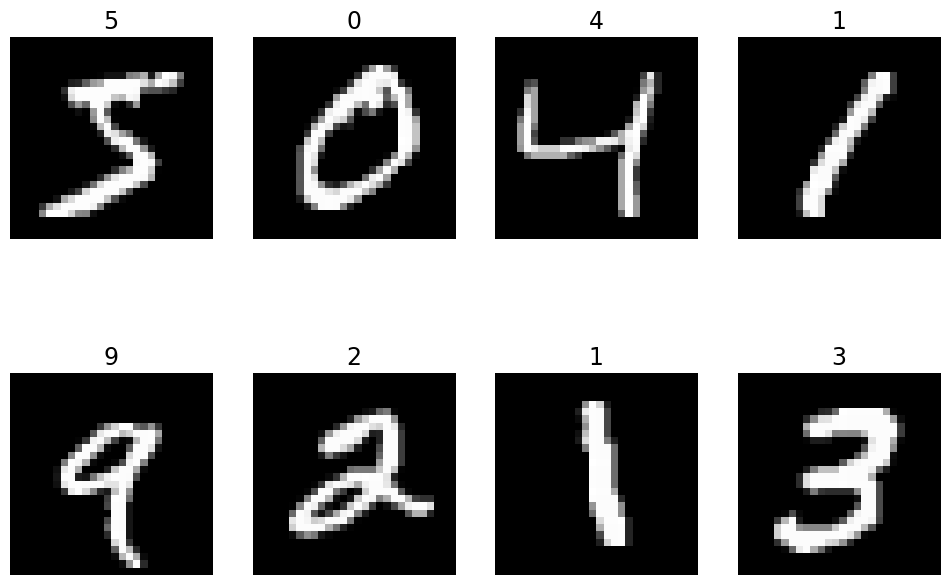

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(8):
  plt.subplot(240 + i + 1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(y_train[i], fontsize=17)
  plt.axis("off")

plt.show()


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train.shape

(5000, 28, 28)

In [ ]:
X_train = X_train.reshape(-1, 28**2)
X_train.shape

(5000, 784)

In [ ]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_train_pca[:5]

array([[ 0.45547384,  1.44641879,  0.12658194],
       [ 4.06776706,  1.51569184, -2.16290599],
       [-0.11157668, -1.77792653,  0.61830724],
       [-3.43948994,  2.33769983, -0.61054726],
       [-1.40301322, -2.69508602,  0.17214352]])

In [ ]:
results = pd.DataFrame({"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.098676,0.098676,1
1,0.074045,0.172721,2
2,0.061277,0.233998,3


In [ ]:
fig  = go.Figure(data=[go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="explained variance ratio"),
                      go.Scatter(x=results["component"], y=results["cumulative"], name="cumulative explained variance")])
fig.show()

In [ ]:
X_train_pca_df = pd.DataFrame(data=np.c_[X_train_pca, y_train], columns=["pca_1", "pca_2", "pca_3", "class"])
X_train_pca_df["class"] = X_train_pca_df["class"].astype(str)
X_train_pca_df.head()

,pca_1,pca_2,pca_3,class
0,0.455474,1.446419,0.126582,5.0
1,4.067767,1.515692,-2.162906,0.0
2,-0.111577,-1.777927,0.618307,4.0
3,-3.439490,2.337700,-0.610547,1.0
4,-1.403013,-2.695086,0.172144,9.0


In [ ]:
px.scatter_3d(X_train_pca_df, x="pca_1", y="pca_2", z="pca_3", color="class", width=950, height=500, title="PCA dla danych minst", template="plotly_dark", opacity=0.7)

In [ ]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_train_pca[:1]

array([[ 0.45547947,  1.44640473,  0.12655663,  2.04641254,  0.9062279 , -0.86582045,  0.71431437,  0.38428219, -1.21694474,  0.57364445, -0.22328529, -1.81756856,  1.06965068, -2.88461682,
        -0.04345995,  0.40545133, -1.35171655,  0.48809479,  0.74392129, -1.25593215, -0.49099363, -0.89711903, -0.71566793,  0.78227674,  0.24740114,  0.36422054,  1.31173026,  0.43689339,
        -0.45146487,  0.15557871, -0.59054645, -0.03177077, -0.08793944,  0.15449585, -0.17571162, -0.44335786, -0.72367008, -0.35609599,  0.44318513, -1.71119188,  0.26734519, -0.84390829,
         0.38941395, -0.15283391, -0.04403904,  0.51247248, -0.61940769,  0.19681912, -0.2109247 , -0.39944693, -0.31065904, -0.09066386,  0.13612481,  0.59260145, -0.01473146,  0.71612222,
         0.49696565, -0.61632946, -0.28841383,  0.16266513, -0.56855196, -0.12770368, -0.65453375, -0.34065393,  0.7817326 ,  0.25856926, -0.05667748,  0.24882996,  0.33123775,  0.10654711,
         0.035182  ,  0.63059981,  0.01242583, -0.

In [ ]:
X_train_pca.shape

(5000, 148)

In [ ]:
pca.n_components_

np.int64(148)

In [ ]:
results = pd.DataFrame({"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.098676,0.098676,1
1,0.074045,0.172721,2
2,0.061277,0.233998,3
3,0.054053,0.288051,4
4,0.047376,0.335427,5
...,...,...,...
143,0.000497,0.948219,144
144,0.000491,0.948711,145
145,0.000482,0.949193,146
146,0.000473,0.949665,147


In [ ]:
fig  = go.Figure(data=[go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="explained variance ratio"),
                      go.Scatter(x=results["component"], y=results["cumulative"], name="cumulative explained variance")])
fig.show()

In [ ]:
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
X_train = X_train[:5000]
y_train = y_train[:5000]
X_train[0].shape

(32, 32, 3)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

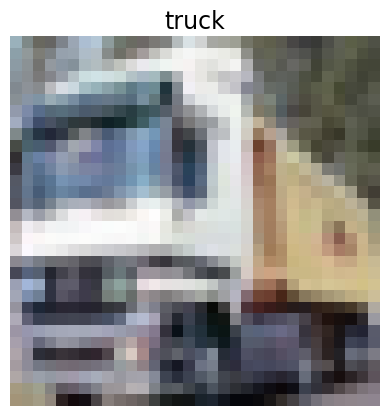

In [ ]:
targets = {0 : "airplane", 1 : "automobile", 2 : "bird", 3 : "cat", 4 : "deer", 5 : "dog", 6 : "frog", 7 : "horse", 8 : "ship", 9 : "truck"}

plt.imshow(X_train[1])
plt.title(targets[y_train[1][0]], fontsize=17)
plt.axis("off")
plt.show()

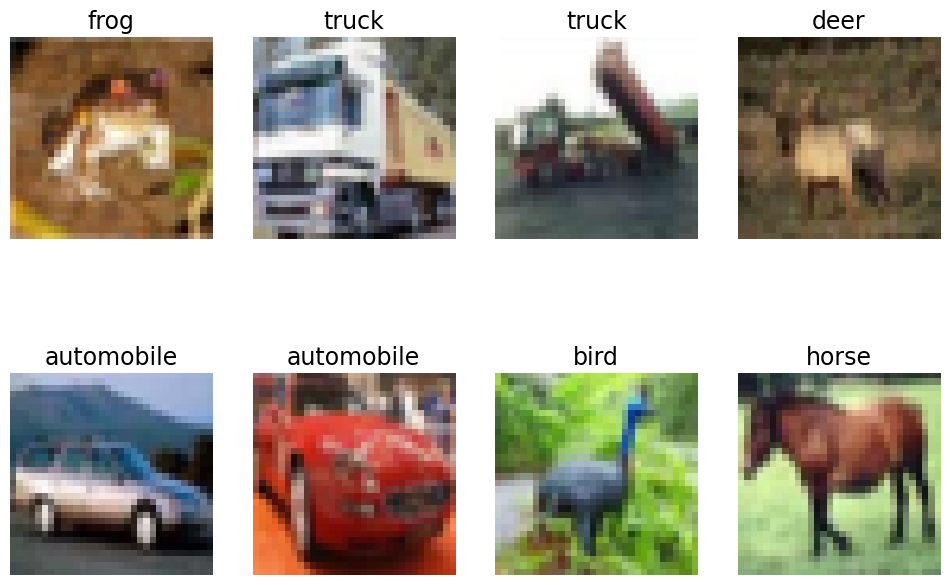

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(8):
  plt.subplot(240 +i + 1)
  plt.imshow(X_train[i])
  plt.title(targets[y_train[i][0]], fontsize=17)
  plt.axis("off")

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train.shape

(5000, 32, 32, 3)

In [ ]:
X_train = X_train.reshape(-1, 32*32*3)
X_train.shape

(5000, 3072)

In [ ]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_train_pca[:5]

array([[ -6.50231806,   2.55047991,   1.57722293],
       [  0.87089031,  -0.87150009,   6.21631322],
       [  8.11101293, -11.19478981,  -2.69116612],
       [-10.35215989,  -0.23942373,   1.25219203],
       [ -2.46193879,  -4.834697  ,   1.24786369]])

In [ ]:
results = pd.DataFrame({"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.291944,0.291944,1
1,0.112451,0.404395,2
2,0.066359,0.470754,3
